<a href="https://colab.research.google.com/github/Lemusidk/Patrones_anomalos/blob/main/Examen_ejercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_excel("/content/Consumo Gasolina Autos Ene 2018.xlsx")
df.head()

,Marca,Submarca,Versión,Modelo,Trans.,Comb.,Cilindros,Potencia (HP),Tamaño (L),Categoría,R. Ciudad (km/l),R. Carr. (km/l),R. Comb. (km/l),R. Ajust. (km/l),CO2(g/km),NOx (g/1000km),Calificación Gas Ef. Inv.,Calificación Contam. Aire
0,FORD,FUSION,HIBRIDO 4PTS 2.0L 4CIL 188HP AUT (CVT),2015,CVT,Gasolina,4,188,2.0,AUTOS COMPACTOS,27.44,28.57,28.93,21.70,107,5,10,9
1,FORD,FUSION,HIBRIDO 4PTS 2.0L 4CIL 188HP AUT (eCVT),2016,CVT,Gasolina,4,188,2.0,AUTOS COMPACTOS,27.44,28.57,28.93,21.70,107,0,10,9
2,FORD,FUSION,HIBRIDO 4X2 4PTAS 2.0L 4CIL 141(+47e)HP E-CVT,2017,CVT,Gasolina,4,188,2.0,AUTOS COMPACTOS,25.62,24.77,25.23,18.92,123,2,10,9
3,FORD,FUSION,HIBRIDO 4PTAS 2.0L 4CIL 188HP AUT eCVT,2018,AUT,Gasolina,4,188,2.0,AUTOS COMPACTOS,25.62,24.77,25.23,18.92,123,2,10,9
4,FORD,FUSION,HYBRID 4PTS 2.5L 4CIL 156HP CVT,2011,CVT,Gasolina,4,156,2.5,AUTOS COMPACTOS,24.00,21.90,23.01,17.26,135,5,9,9


2. Detección de patrones anómalos de consumo
La gerencia sospecha que existen registros atípicos que podrían representar errores de captura o uso
irregular de combustible.

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
df_numeric = df[['Marca', 'Submarca']].copy()
df_numeric = pd.concat([df_numeric, df[numeric_cols]], axis=1)
display(df_numeric.head())

,Marca,Submarca,Modelo,Cilindros,Potencia (HP),Tamaño (L),R. Ciudad (km/l),R. Carr. (km/l),R. Comb. (km/l),R. Ajust. (km/l),CO2(g/km),NOx (g/1000km),Calificación Gas Ef. Inv.
0,FORD,FUSION,2015,4,188,2.0,27.44,28.57,28.93,21.70,107,5,10
1,FORD,FUSION,2016,4,188,2.0,27.44,28.57,28.93,21.70,107,0,10
2,FORD,FUSION,2017,4,188,2.0,25.62,24.77,25.23,18.92,123,2,10
3,FORD,FUSION,2018,4,188,2.0,25.62,24.77,25.23,18.92,123,2,10
4,FORD,FUSION,2011,4,156,2.5,24.00,21.90,23.01,17.26,135,5,9


In [ ]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Marca                      4617 non-null   object 
 1   Submarca                   4617 non-null   object 
 2   Modelo                     4617 non-null   int64  
 3   Cilindros                  4617 non-null   int64  
 4   Potencia (HP)              4617 non-null   int64  
 5   Tamaño (L)                 4617 non-null   float64
 6   R. Ciudad (km/l)           4617 non-null   float64
 7   R. Carr. (km/l)            4617 non-null   float64
 8   R. Comb. (km/l)            4617 non-null   float64
 9   R. Ajust. (km/l)           4617 non-null   float64
 10  CO2(g/km)                  4617 non-null   int64  
 11  NOx (g/1000km)             4617 non-null   int64  
 12  Calificación Gas Ef. Inv.  4617 non-null   int64  
dtypes: float64(5), int64(6), object(2)
memory usage:

In [ ]:
null_counts = df_numeric.isnull().sum()
null_columns = null_counts[null_counts > 0]

if not null_columns.empty:
    print("Columnas con valores nulos: ")
    display(null_columns)
else:
    print("No se encontraron valores nulos")

No se encontraron valores nulos


In [ ]:
negative_check = (df_numeric.select_dtypes(include=['number']) < 0).any().any()

if negative_check:
    print("Sí, se encontraron valores negativos")
else:
    print("No, no se encontraron valores negativos")

No, no se encontraron valores negativos


In [ ]:
df_numeric.count()

,0
Marca,4617
Submarca,4617
Modelo,4617
Cilindros,4617
Potencia (HP),4617
Tamaño (L),4617
R. Ciudad (km/l),4617
R. Carr. (km/l),4617
R. Comb. (km/l),4617
R. Ajust. (km/l),4617


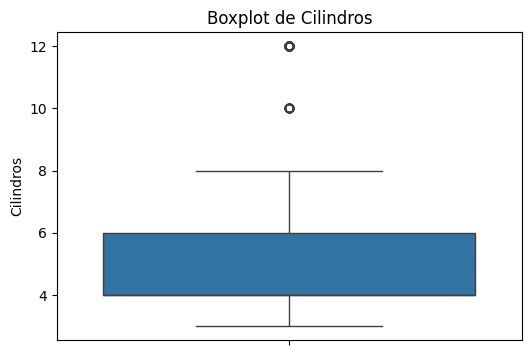

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['Cilindros'])
plt.title('Boxplot de Cilindros')
plt.ylabel('Cilindros')
plt.show()


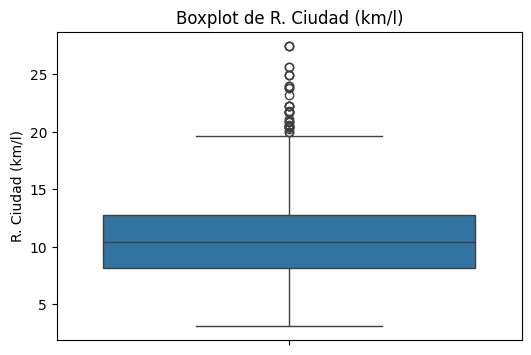

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['R. Ciudad (km/l)'])
plt.title('Boxplot de R. Ciudad (km/l)')
plt.ylabel('R. Ciudad (km/l)')
plt.show()

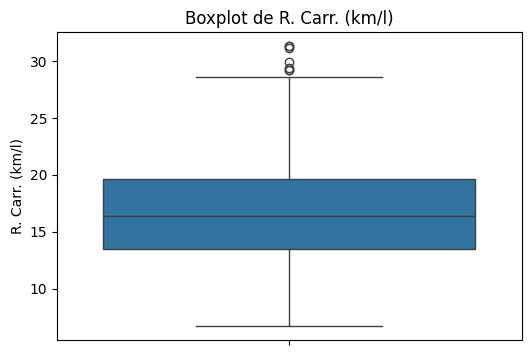

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['R. Carr. (km/l)'])
plt.title('Boxplot de R. Carr. (km/l)')
plt.ylabel('R. Carr. (km/l)')
plt.show()

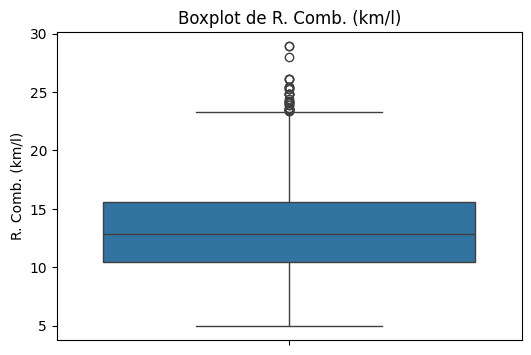

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['R. Comb. (km/l)'])
plt.title('Boxplot de R. Comb. (km/l)')
plt.ylabel('R. Comb. (km/l)')
plt.show()

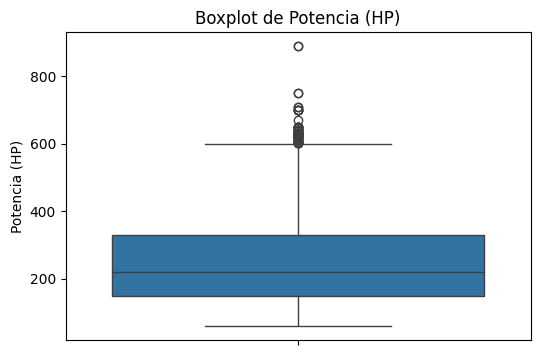

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['Potencia (HP)'])
plt.title('Boxplot de Potencia (HP)')
plt.ylabel('Potencia (HP)')
plt.show()

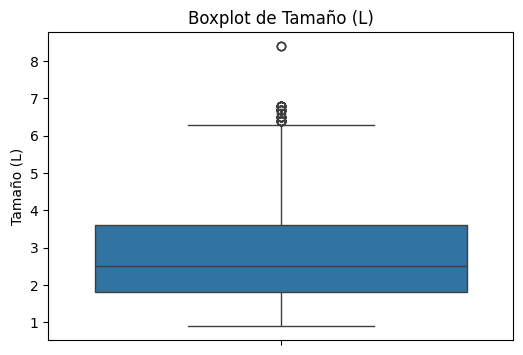

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['Tamaño (L)'])
plt.title('Boxplot de Tamaño (L)')
plt.ylabel('Tamaño (L)')
plt.show()

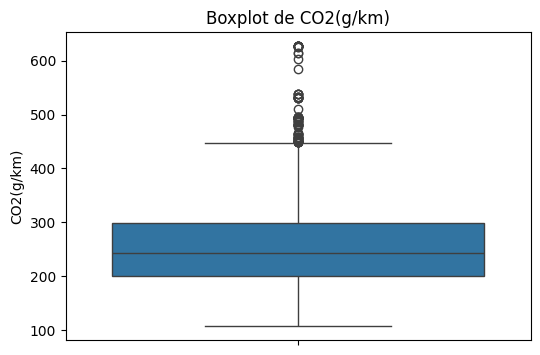

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_numeric['CO2(g/km)'])
plt.title('Boxplot de CO2(g/km)')
plt.ylabel('CO2(g/km)')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = [
    'R. Ciudad (km/l)',
    'R. Carr. (km/l)',
    'R. Comb. (km/l)',
    'CO2(g/km)',
    'Potencia (HP)',
    'Tamaño (L)',
    'Cilindros'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df['Anomalia_IF'] = iso.fit_predict(X_scaled)


In [ ]:
df['Anomalia'] = df['Anomalia_IF'].apply(
    lambda x: 'Anómalo' if x == -1 else 'Normal'
)
df['Anomalia'].value_counts()


,count
Anomalia,
Normal,4388
Anómalo,229


<Axes: xlabel='Anomalia', ylabel='R. Comb. (km/l)'>

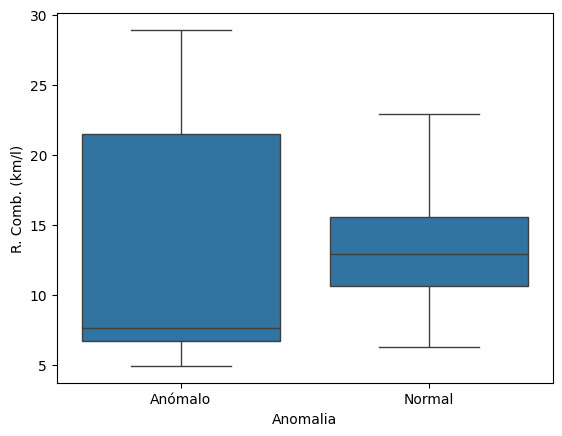

In [ ]:
import seaborn as sns
sns.boxplot(x='Anomalia', y='R. Comb. (km/l)', data=df)


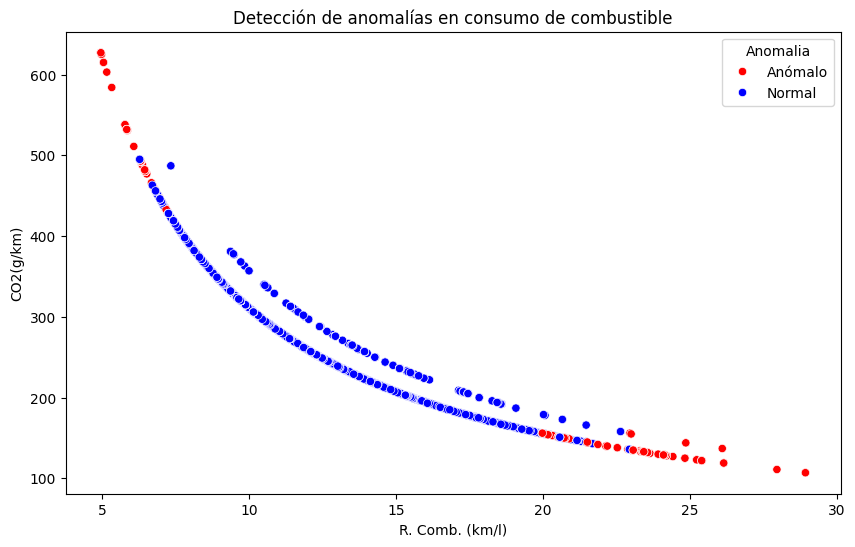

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='R. Comb. (km/l)',
    y='CO2(g/km)',
    hue='Anomalia',
    palette={'Normal':'blue', 'Anómalo':'red'}
)
plt.title('Detección de anomalías en consumo de combustible')
plt.show()


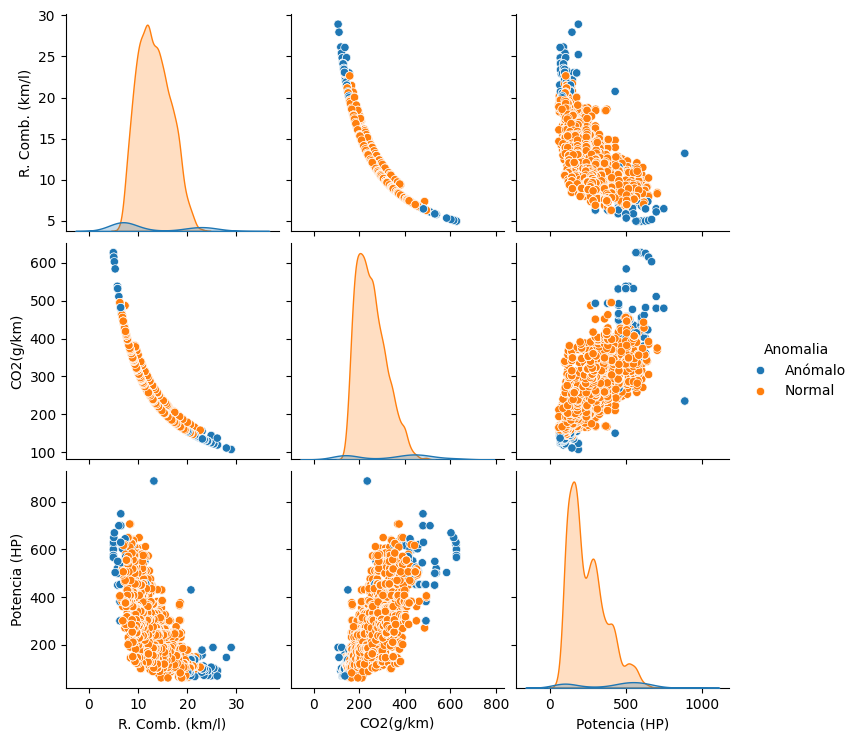

In [ ]:
sns.pairplot(
    df,
    vars=['R. Comb. (km/l)', 'CO2(g/km)', 'Potencia (HP)'],
    hue='Anomalia'
)


In [ ]:
df['Anomalia'].value_counts(normalize=True)


,proportion
Anomalia,
Normal,0.950401
Anómalo,0.049599


In [ ]:
df.groupby('Anomalia')['R. Comb. (km/l)'].describe()


,count,mean,std,min,25%,50%,75%,max
Anomalia,,,,,,,,
Anómalo,229.0,12.484410,7.640857,4.96,6.71,7.69,21.51,28.93
Normal,4388.0,13.220303,3.255880,6.28,10.64,12.94,15.56,22.94


In [ ]:
df_anom = df[df['Anomalia'] == 'Anómalo']
df_anom.sort_values('R. Comb. (km/l)').head(10)


,Marca,Submarca,Versión,Modelo,Trans.,Comb.,Cilindros,Potencia (HP),Tamaño (L),Categoría,R. Ciudad (km/l),R. Carr. (km/l),R. Comb. (km/l),R. Ajust. (km/l),CO2(g/km),NOx (g/1000km),Calificación Gas Ef. Inv.,Calificación Contam. Aire,Anomalia_IF,Anomalia
2251,BENTLEY,CONTINENTAL,FLYING SPUR 4X4 4PTS 6.0L 12CIL 600HP TIP DOBL...,2012,TIP,Gasolina,12,600,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2250,BENTLEY,CONTINENTAL,FLYING SPUR 4X4 4PTS 6.0L 12CIL 567HP TIP DOBL...,2012,TIP,Gasolina,12,567,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2254,BENTLEY,CONTINENTAL,GTC 4X4 2PTS 6.0L 12CIL 567HP TIP DOBLE TURBO ...,2012,TIP,Gasolina,12,567,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2255,BENTLEY,CONTINENTAL,GTC 4X4 2PTS 6.0L 12CIL 600HP TIP DOBLE TURBO ...,2012,TIP,Gasolina,12,600,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2253,BENTLEY,CONTINENTAL,GT 4X4 2PTS 6.0L 12CIL 600HP TIP DOBLE TURBO Q...,2012,TIP,Gasolina,12,600,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2252,BENTLEY,CONTINENTAL,GT 4X4 2PTS 6.0L 12CIL 567HP TIP DOBLE TURBO Q...,2012,TIP,Gasolina,12,567,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2260,BENTLEY,CONTINENTAL,GTC 2PTS 6.0L 12CIL 575HP TIP DOBLE TURBO QUATTRO,2013,TIP,Gasolina,12,575,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2259,BENTLEY,CONTINENTAL,GT 2PTS 6.0L 12CIL 575HP TIP DOBLE TURBO QUATTRO,2013,TIP,Gasolina,12,575,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2261,BENTLEY,CONTINENTAL,FLYING SPUR 4PTS 6.0L 12CIL 575HP TIP DOBLE TU...,2013,TIP,Gasolina,12,575,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,6,0,9,-1,Anómalo
2263,BENTLEY,CONTINENTAL,GT 2PTS 6.0L 12CIL 567HP ZF8 QUATTRO BITURBO,2014,ZF SPEED QUICKSHIFT,Gasolina,12,567,6.0,AUTOS DE LUJO,4.0,7.0,4.96,3.72,627,15,0,8,-1,Anómalo


In [ ]:
df['Anomalia_numeric'] = df['Anomalia'].apply(lambda x: 1 if x == 'Anómalo' else 0)
display(df[['Anomalia', 'Anomalia_numeric']].head())

,Anomalia,Anomalia_numeric
0,Anómalo,1
1,Anómalo,1
2,Anómalo,1
3,Anómalo,1
4,Anómalo,1


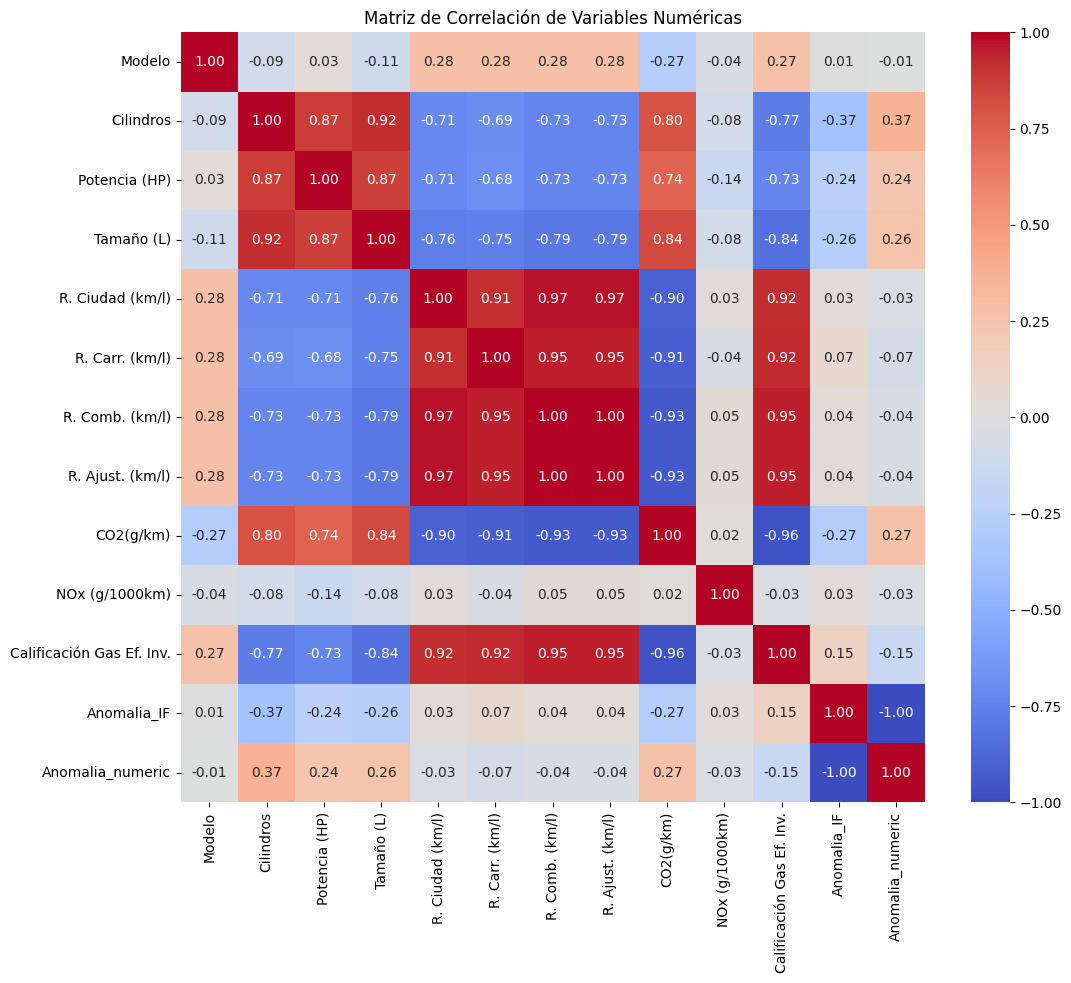

In [ ]:
numeric_cols = df.select_dtypes(include=['number'])

correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [ ]:
import os

columns_export = [
    'Marca',
    'Modelo',
    'R. Ciudad (km/l)',
    'R. Carr. (km/l)',
    'R. Comb. (km/l)',
    'CO2(g/km)',
    'Potencia (HP)',
    'Tamaño (L)',
    'Anomalia'
]

output_dir = 'data/model_outputs'
os.makedirs(output_dir, exist_ok=True)

df[columns_export].to_csv(
    os.path.join(output_dir, 'anomalias_consumo.csv'),
    index=False
)